# RBF - Cas d'images


In [ ]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join("..", "python")))

import numpy as np
import matplotlib.pyplot as plt
from rbf import lib, entrainer_rbf, predire_rbf, precision_rbf


In [7]:
from functions import load_dataset, melanger

project_root = os.path.abspath("..")
train_folder = os.path.join(project_root, "dataset", "train_dataset")
test_folder = os.path.join(project_root, "dataset", "test_dataset")

X_train_img, Y_train_img = load_dataset(train_folder, target_size=(16, 16), color=True)
X_test_img, Y_test_img = load_dataset(test_folder, target_size=(16, 16), color=True)
X_train_img, Y_train_img = melanger(X_train_img, Y_train_img, seed=42)

print(f"train={len(X_train_img)} test={len(X_test_img)}")


def courbe(x, y, xlabel, ylabel, titre, log=False):
    plt.plot(x, y, marker="o")
    if log:
        plt.xscale("log")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(titre)
    plt.show()

def courbe_train_test(x, accs_train, accs_test, xlabel, titre, log=False):
    plt.plot(x, accs_train, marker="o", label="train")
    plt.plot(x, accs_test, marker="o", label="test")
    if log:
        plt.xscale("log")
    plt.xlabel(xlabel)
    plt.ylabel("precision (%)")
    plt.legend()
    plt.title(titre)
    plt.show()

train=2400 test=600


### 5.1 Effet de gamma

K fixe a 100. Meme logique que le cercle : gamma trop petit -> bosses trop
larges -> sous-apprentissage ; gamma trop grand -> bosses trop etroites ->
sur-apprentissage.

gamma=1e-05 | train=55.29% test=51.67%
gamma=0.0001 | train=56.54% test=52.33%
gamma=0.001 | train=57.54% test=55.67%
gamma=0.01 | train=58.38% test=55.83%
gamma=0.1 | train=54.79% test=52.33%
gamma=1.0 | train=43.46% test=41.67%


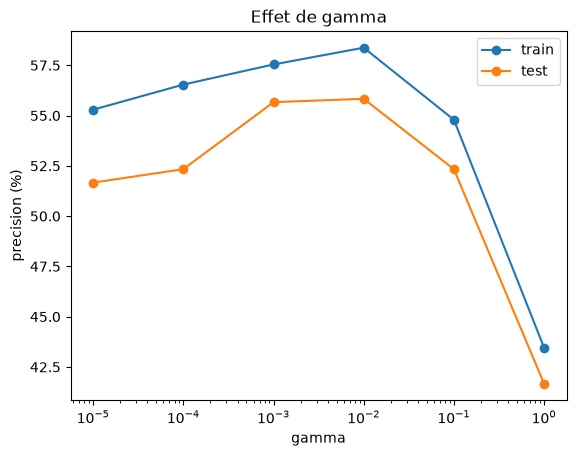

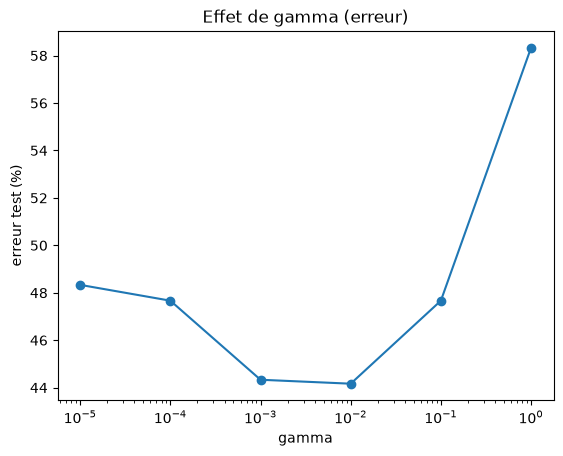

Meilleur gamma: 0.01


In [8]:
K_EXPLO = 100
gammas = [0.00001, 0.0001, 0.001, 0.01, 0.1, 1.0]

accs_train, accs_test = [], []
for gamma in gammas:
    model = entrainer_rbf(X_train_img, Y_train_img, n_centres=K_EXPLO, gamma=gamma)
    accs_train.append(precision_rbf(model, X_train_img, Y_train_img))
    accs_test.append(precision_rbf(model, X_test_img, Y_test_img))
    lib.destroy_rbf_model(model)
    print(f"gamma={gamma} | train={accs_train[-1]:.2f}% test={accs_test[-1]:.2f}%")

courbe_train_test(gammas, accs_train, accs_test, "gamma", "Effet de gamma", log=True)
courbe(gammas, [100 - a for a in accs_test], "gamma", "erreur test (%)", "Effet de gamma (erreur)", log=True)

meilleur_gamma = gammas[int(np.argmax(accs_test))]
print(f"Meilleur gamma: {meilleur_gamma}")

### 5.2 Effet du nombre de centres K

Avec le meilleur gamma. Plus de centres = plus de capacite : trop peu ->
sous-apprentissage, trop -> sur-apprentissage (et entrainement plus lent).

K=10 | train=45.79% test=43.83%
K=25 | train=53.33% test=53.00%
K=50 | train=56.58% test=55.33%
K=100 | train=58.38% test=55.83%
K=200 | train=63.04% test=55.33%
K=400 | train=70.29% test=54.50%


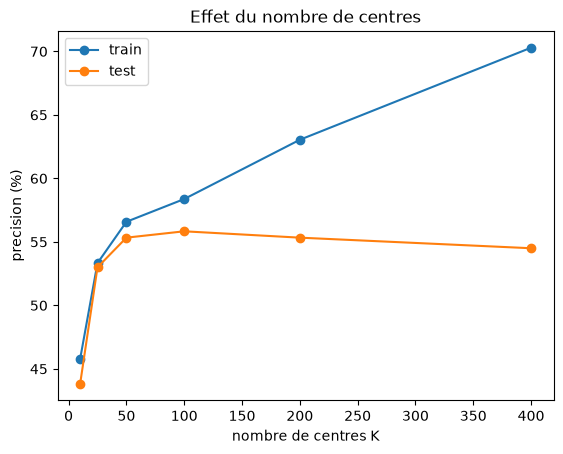

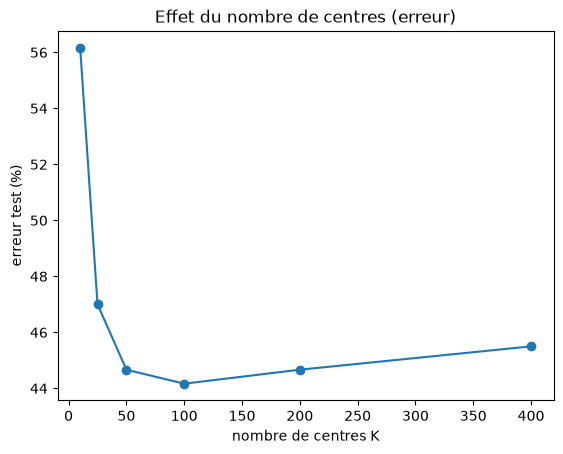

Meilleur K: 100


In [9]:
Ks = [10, 25, 50, 100, 200, 400]

accs_train, accs_test = [], []
for K in Ks:
    model = entrainer_rbf(X_train_img, Y_train_img, n_centres=K, gamma=meilleur_gamma)
    accs_train.append(precision_rbf(model, X_train_img, Y_train_img))
    accs_test.append(precision_rbf(model, X_test_img, Y_test_img))
    lib.destroy_rbf_model(model)
    print(f"K={K} | train={accs_train[-1]:.2f}% test={accs_test[-1]:.2f}%")

courbe_train_test(Ks, accs_train, accs_test, "nombre de centres K", "Effet du nombre de centres")
courbe(Ks, [100 - a for a in accs_test], "nombre de centres K", "erreur test (%)", "Effet du nombre de centres (erreur)")

meilleur_K = Ks[int(np.argmax(accs_test))]
print(f"Meilleur K: {meilleur_K}")

### 5.3 Modele final

Entrainement avec le gamma et le K retenus, matrice de confusion, puis
sauvegarde et verification par rechargement.

train=58.38%  test=55.83%


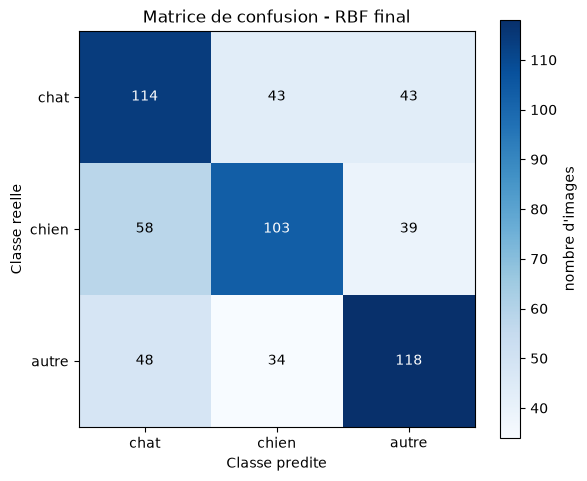

In [11]:
model_final = entrainer_rbf(X_train_img, Y_train_img, n_centres=meilleur_K, gamma=meilleur_gamma)
print(f"train={precision_rbf(model_final, X_train_img, Y_train_img):.2f}%  "
      f"test={precision_rbf(model_final, X_test_img, Y_test_img):.2f}%")

noms_classes = ["chat", "chien", "autre"]

def matrice_confusion(model, X, Y, nb_classes=3):
    matrice = np.zeros((nb_classes, nb_classes), dtype=int)
    for x, y_vrai in zip(X, Y):
        y_pred = predire_rbf(model, x)
        matrice[y_vrai][y_pred] += 1
    return matrice

cm = matrice_confusion(model_final, X_test_img, Y_test_img)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(noms_classes)))
ax.set_yticks(range(len(noms_classes)))
ax.set_xticklabels(noms_classes)
ax.set_yticklabels(noms_classes)
ax.set_xlabel("Classe predite")
ax.set_ylabel("Classe reelle")
ax.set_title("Matrice de confusion - RBF final")

seuil = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        couleur_texte = "white" if cm[i, j] > seuil else "black"
        ax.text(j, i, cm[i, j], ha="center", va="center", color=couleur_texte)

fig.colorbar(im, ax=ax, label="nombre d'images")
plt.tight_layout()
plt.show()

In [12]:
chemin = os.path.join(project_root, "models", "rbf_chat_chien_autre.txt")
lib.save_rbf_model(model_final, chemin.encode())
lib.destroy_rbf_model(model_final)

model_charge = lib.load_rbf_model(chemin.encode())
print(f"test_acc (modele recharge) = {precision_rbf(model_charge, X_test_img, Y_test_img):.2f}%")
lib.destroy_rbf_model(model_charge)

test_acc (modele recharge) = 55.83%
